### Tugas Online
Tahap awal untuk menyiapkan semua peralatan kode yang dibutuhkan. Kita mengimpor `pandas` untuk olah data, `matplotlib` untuk grafik, `skforecast` untuk model peramalan waktu, `lightgbm` sebagai mesin algoritma dasar, serta `shap` dan `sklearn` untuk melakukan analisis transparansi keputusan model.

In [4]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

### Mengunduh Dataset Mentah
Mengunduh dataset historis `vic_electricity` langsung via fitur bawaan `skforecast`. Data ini berisi rekaman konsumsi listrik harian beserta suhu udara di wilayah Victoria, Australia. Kode `data.head(3)` digunakan untuk mengintip 3 baris pertama data.


In [5]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


### Mengubah Data Menjadi Skala Harian (Resampling)
Data asli yang terekam per 30 menit digabungkan menjadi skala harian (`'D'`). Total konsumsi listrik harian dijumlahkan (`'sum'`), sedangkan suhu udara harian diambil nilai rata-ratanya (`'mean'`) agar data lebih konsisten untuk peramalan jangka panjang.

In [6]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


### Memisahkan Data Latih dan Data Uji (Split Train-Test)
Membagi data menjadi dua bagian: data hingga tanggal 21 Desember 2014 digunakan sebagai data latih (`data_train`) untuk membangun model, dan data setelah tanggal tersebut dijadikan data uji (`data_test`) untuk menguji keakuratan tebakan model.

In [8]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

### Inisialisasi dan Pelatihan Model Peramalan
Membuat objek peramalan menggunakan `ForecasterRecursive` dengan algoritma `LGBMRegressor`. Model ini dikonfigurasi untuk melihat data 7 hari ke belakang (`lags=7`) dan memanfaatkan suhu (`exog`) untuk menebak total konsumsi listrik di masa depan.

In [11]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 03:55:38 
Last fit date: 2026-06-11 03:55:38 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

### Melihat Tingkat Kepentingan Fitur secara Global
Menjalankan perintah `forecaster.get_feature_importances()` untuk mengintip fitur atau variabel mana yang paling sering digunakan dan dianggap paling krusial oleh model dalam menentukan keputusan peramalan secara umum.

In [12]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


### Mengekstrak Matriks Data Latih Internal
Menggunakan fungsi `create_train_X_y` untuk membedah bentuk tabel data ($X$ dan $y$) yang dibuat secara otomatis oleh `skforecast` di latar belakang sebelum dimasukkan ke dalam algoritma pelatihan *machine learning*.

In [13]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


### Menyiapkan Alat Bedah SHAP (Explainer)
Mengaktifkan fungsionalitas JavaScript lewat `shap.initjs()` dan membuat objek `TreeExplainer` yang diarahkan langsung ke mesin model kita (`forecaster.estimator`). Langkah ini krusial untuk menghitung kontribusi nilai (*SHAP values*) pada setiap baris data.

In [18]:
# 1. Inisialisasi JS untuk SHAP
shap.initjs()

# 2. Ganti forecaster.regressor menjadi forecaster.estimator
explainer = shap.TreeExplainer(forecaster.estimator)

# 3. Hitung SHAP values
shap_values = explainer.shap_values(X_train)


### Grafik SHAP Summary Plot (Model Bar)
Menampilkan grafik batang (*bar plot*) dari nilai SHAP untuk mengurutkan variabel dari yang paling berpengaruh hingga yang kurang berpengaruh terhadap hasil prediksi konsumsi listrik secara keseluruhan.

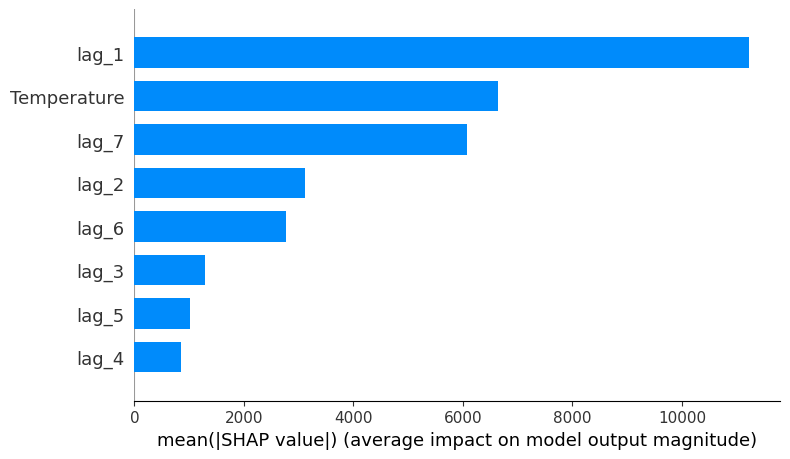

In [19]:

shap.summary_plot(shap_values, X_train, plot_type="bar")

### Grafik Distribusi Pengaruh Fitur (SHAP Density Plot)
Menampilkan grafik titik SHAP untuk melihat arah pengaruh variabel. Melalui grafik ini, kita bisa membaca apakah nilai suhu yang tinggi akan mendorong prediksi konsumsi listrik menjadi naik atau justru malah menurunkannya.

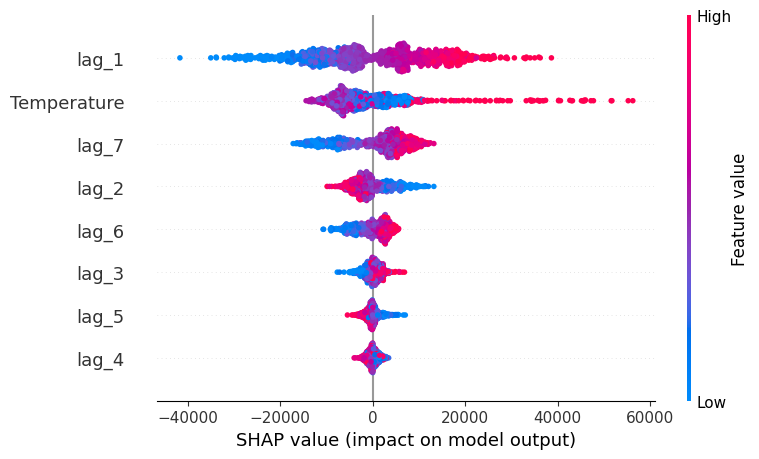

In [20]:
shap.summary_plot(shap_values, X_train)

### Membedah Alasan Prediksi pada Baris Data Pertama
Menggunakan *Force Plot* untuk menganalisis keputusan model secara spesifik (lokal) pada baris data pertama. Grafik ini akan menunjukkan faktor apa saja yang mendorong angka prediksi naik (merah) atau menahannya turun (biru) pada hari tersebut.

In [22]:
shap.initjs()  # Tambahkan ini di sel yang sama
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

### Visualisasi Kolektif Force Plot (200 Data Pertama)
Menggabungkan visualisasi *Force Plot* untuk 200 baris data pertama sekaligus. Grafik interaktif ini sangat berguna untuk melihat perubahan tren keputusan model seiring berjalannya waktu atau perubahan pola data.

In [24]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

### Analisis Ketergantungan Variabel Suhu (Dependence Plot)
Membuat grafik khusus untuk melihat hubungan linier atau non-linier antara fluktuasi variabel `Temperature` terhadap perubahan nilai prediksi, sekaligus mendeteksi interaksinya dengan variabel pendukung lain.

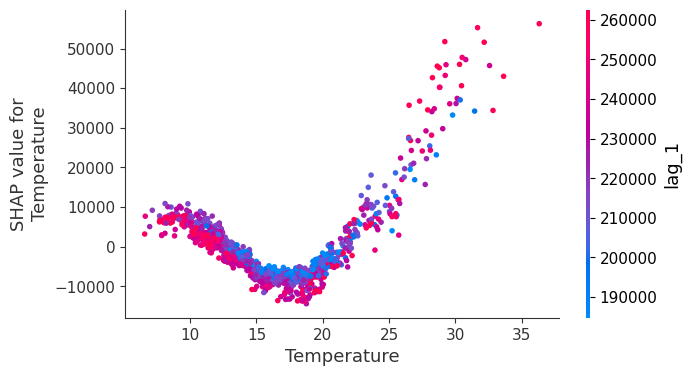

In [25]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

### Melakukan Peramalan Masa Depan (Predict)
Memerintahkan model yang telah dilatih untuk melakukan peramalan konsumsi listrik sebanyak 10 langkah ke depan (`steps=10`) dengan memasukkan data prediktor suhu dari masa data uji (`data_test`).

In [26]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


### Membuat Matriks Input untuk Proses Prediksi
Melihat bentuk matriks data ($X$) yang diatur secara otomatis oleh fungsi internal model sewaktu memproses langkah peramalan masa depan (tabel lag yang bergeser secara rekursif).

In [27]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


### Membedah Alasan Hasil Ramalan Tanggal 22 Desember 2014
Menerapkan analisis *Force Plot* pada hasil tebakan masa depan untuk tanggal spesifik ('2014-12-22'). Ini membantu memberikan pertanggungjawaban logis mengapa model meramal angka kebutuhan listrik sebesar itu pada tanggal tersebut.

In [29]:
# Force plot for a specific prediction
# ==============================================================================
shap.initjs()
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

### Memuat Ulang Matriks Latih untuk Evaluasi Lanjutan
Menyiapkan kembali pasangan data $X\_train$ dan $y\_train$ dari model guna mempersiapkan pengujian sensitivitas alternatif menggunakan fitur evaluasi bawaan dari `scikit-learn`.

In [31]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
    estimator    = forecaster.estimator,  # Ganti dari forecaster.regressor menjadi forecaster.estimator
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


### Grafik Ketergantungan Parsial (Partial Dependence Plots)
Menampilkan visualisasi akhir menggunakan modul `sklearn.inspection` untuk mengukur efek marjinal dari satu atau dua fitur terpilih terhadap hasil prediksi model *decision tree*, sebagai validasi pelengkap dari hasil SHAP.

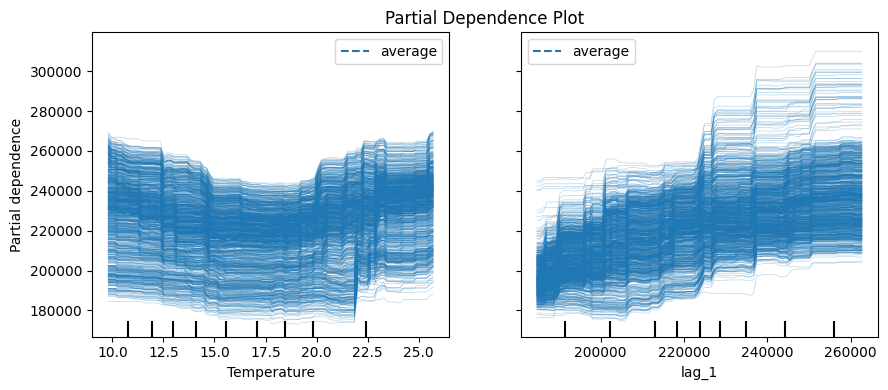

In [33]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator    = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

# Jawaban Pertanyaan

---

## 1. Analisis Prediksi tentang Apa?
Analisis ini membahas tentang **peramalan harian kebutuhan listrik (*daily electricity demand*)** di wilayah Victoria, Australia.

Selain memprediksi angka konsumsi di masa depan, fokus utamanya adalah **Model Explainability (Keterjelasan Model)**, yaitu membongkar cara kerja model *machine learning* (yang biasanya bersifat *black box*) untuk memahami faktor apa saja yang paling memengaruhi naik-turunnya konsumsi listrik (misalnya cuaca atau pola hari sebelumnya).

---

## 2. Struktur Data Training (Input & Output)
Data mentah yang awalnya berskala per 30 menit digabungkan (*aggregated*) menjadi skala harian. Berikut adalah bentuk matriks input ($X$) dan output ($y$) yang digunakan untuk melatih model:

| Jenis Variabel | Nama Kolom / Fitur | Deskripsi / Keterangan |
| :--- | :--- | :--- |
| **Output (Target / $y$)** | `Demand` | Total konsumsi listrik harian yang ingin diprediksi. |
| **Input (Features / $X$)** | `lag_1` s.d. `lag_7` | Nilai konsumsi listrik dari 1 hari lalu hingga 7 hari lalu. |
| **Input (Exogenous / $X$)**| `Temperature` | Rata-rata suhu udara pada hari tersebut (faktor eksternal). |

---

## 3. Apa itu *Lag*?
Dalam analisis deret waktu (*time series*), **Lag adalah nilai masa lalu dari variabel target itu sendiri** yang digunakan sebagai fitur masukan untuk memprediksi masa depan. Karena data ini bersifat harian, maka artinya:
* **`lag_1`**: Konsumsi listrik 1 hari yang lalu (kemarin).
* **`lag_2`**: Konsumsi listrik 2 hari yang lalu.
* **`lag_7`**: Konsumsi listrik 7 hari yang lalu (hari yang sama di minggu lalu, berguna untuk menangkap pola mingguan).

Model membutuhkan *lag* karena pola deret waktu hari ini umumnya memiliki keterkaitan atau ketergantungan yang kuat dengan apa yang terjadi pada hari-hari sebelumnya.

---

## 4. Proses Analisis yang Dilakukan
Eksperimen di dalam dokumentasi tersebut berjalan melalui 4 tahapan utama:

1. **Persiapan Data (*Data Preparation*):**
   Mengubah frekuensi data dari per 30 menit menjadi harian menggunakan `.resample('D')`. Konsumsi listrik dijumlahkan, sedangkan suhu dirata-rata. Data kemudian dibagi menjadi `data_train` dan `data_test`.
   
2. **Pelatihan Model (*Model Training*):**
   Membuat objek peramalan menggunakan `ForecasterRecursive` dengan algoritma **LightGBM** (`LGBMRegressor`). Model dikonfigurasi untuk membaca 7 *lags* ke belakang serta menyertakan variabel eksogen `Temperature`.
   
3. **Evaluasi Tingkat Kepentingan Fitur (*Feature Importance*):**
   Menggunakan fungsi `forecaster.get_feature_importances()` untuk melihat fitur yang paling dominan. Hasil visualisasi menunjukkan bahwa **Suhu (`Temperature`)** dan **`lag_1`** memiliki pengaruh terbesar bagi model dalam menentukan hasil prediksi.
   
4. **Visualisasi Keterjelasan Model (*SHAP Values*):**
   Menggunakan pustaka `shap` (khususnya `TreeExplainer`) untuk membedah keputusan model secara visual:
   * **Summary Plot:** Melihat dampak global dan distribusi pengaruh dari setiap fitur.
   * **Force Plot:** Membedah alasan spesifik di balik satu poin prediksi tertentu (analisis lokal).
   * **Dependence Plot:** Melihat bagaimana grafik hubungan antara perubahan nilai suhu terhadap nilai prediksi yang dihasilkan.